In [1]:
import numpy as np
import torch
from torch.autograd import grad
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR

import seaborn as sns
from scipy.io import savemat, loadmat
from torch.optim.lr_scheduler import ExponentialLR, MultiStepLR

import torch.nn as nn
import torch.nn.functional as F
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from scipy.linalg import sqrtm
from chebyshev_utils import *
from GEOMLOSS import samples_loss

import matplotlib as mpl
import matplotlib.font_manager
fpaths = matplotlib.font_manager.findSystemFonts()
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })
matplotlib.rcParams.update({'font.size': 16})


2026-01-18 15:16:06.416159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768767366.429820  104930 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768767366.434625  104930 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Generate data from 2-dimensional OU process with constant diffusion

In [58]:
max_iter = 2000; dt = 0.01; SFI_dt = 0.05;
nsamples = 2000; 
Nsnaps = int(max_iter*(dt/SFI_dt)); 
print(" Nsnaps ", Nsnaps)

D = 5; Ndim = 2; 
np.random.seed(7)
A = np.random.randn(2,2)
B = A@A.T
eigval, _ = np.linalg.eig(B)
print(" matrix B ", B, " eigen-values ", eigval)

beta = 2.0;
samples_full = np.zeros((Nsnaps-1,nsamples,Ndim+1))
omega = D/beta;

mu0_init = 80;
xold =  np.random.normal(mu0_init,4,(nsamples,Ndim))
xnew =  xold + 0;
    
tt = np.zeros((Nsnaps-1,))
np.random.seed(10)
count = 0; 
for i in range(0,max_iter-1):
    if((int(i%(max_iter/Nsnaps))==0) and (i!=0) ):
        samples_full[count,:,0:Ndim] = xold
        samples_full[count,:,Ndim] = dt*i
        tt[count] = dt*i
        count = count + 1;
    
    xnew = xold - (B @ xold.T).T*dt + np.sqrt(2*D*dt)*np.random.normal(0,1,(nsamples,Ndim))
    xold  = xnew + 0; 


### Sub-set the data
tindFM = np.arange(0,20,4)
samples_FM = samples_full[tindFM,:,0:Ndim]
tp = tt[tindFM]
dt = tp[1] - tp[0]
print(samples_FM.shape, " time ", tp, " dt ", dt)
samples_list = [samples_FM[i] for i in range(samples_FM.shape[0])]
nsnaps = len(samples_list); 

 Nsnaps  399
 matrix B  [[ 3.07497479 -0.13439374]
 [-0.13439374  0.16714668]]  eigen-values  [3.08117297 0.1609485 ]
(5, 2000, 2)  time  [0.06 0.26 0.46 0.66 0.86]  dt  0.2


(2000, 2)
(2000, 2)
(2000, 2)
(2000, 2)
(2000, 2)


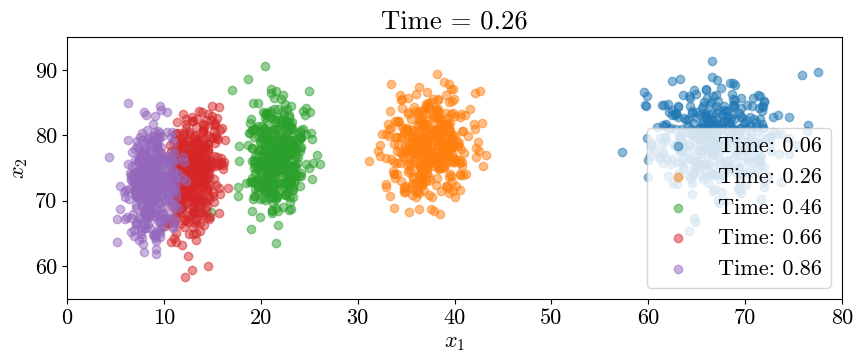

In [59]:
for k in range(0, len(samples_list)):
    print(samples_list[k].shape)
    ind_s = np.arange(0,samples_list[k].shape[0])
    np.random.shuffle(ind_s)
    plt.scatter(samples_list[k][ind_s[0:400],0],samples_list[k][ind_s[0:400],1],alpha=0.5,label='Time: '+str(tp[k]))
    plt.legend(loc='best')
    plt.xlim(0,80); plt.ylim(55,95);
    plt.title(r'Time = '+ str(np.round(tt[k],3)))
    plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.gcf().set_size_inches(10,3.4)

In [60]:
def MMOT_trajectories(samples_):
    nrep = 1;
    print(" # of repetitions ", nrep)

    min_index = np.argmin([arr.shape[0] for arr in samples_])
    nsamples_ = samples_[min_index].shape[0]

    print("Index with fewest samples:", min_index)
    print("Smallest N:", nsamples_)
    
    ### shuffle data to de-correlate the data in time
    Dist_ = np.zeros((len(samples_),nrep,nsamples_,Ndim))   
    for k in range(0, len(samples_)):
        ind_s = np.arange(0,samples_[k].shape[0])
        for j in range(0, nrep):
            np.random.shuffle(ind_s)
            Dist_[k,j,:,:] = samples_[k][ind_s[0:nsamples_],0:Ndim]

    ### Trajectory sampling
    Dist = np.zeros((len(samples_),nrep*nsamples_,Ndim))
    batch_ot_samples  =  torch.tensor(np.zeros((len(samples_),nrep*nsamples_,Ndim)),dtype=torch.float32,device=device)
    for j in range(0, nrep):
        before_ot = torch.tensor(Dist_[:,j,:,0:Ndim],dtype=torch.float32)
        Dist[:,j*nsamples_:(j+1)*nsamples_,:] = Dist_[:,j,:,:]
        before_ot = torch.tensor(Dist[:,j*nsamples_:(j+1)*nsamples_,:],dtype=torch.float32)
        batch_ot_samples[:,j*nsamples_:(j+1)*nsamples_,:] = mmot_trajectories(before_ot,nsamples_,device);

    return Dist, batch_ot_samples
        
Dist, batch_ot_samples = MMOT_trajectories(samples_list) #batch_ot_samples
nsamples = Dist.shape[1] + 0;
print(" nsamples ", nsamples, Dist.shape)

 # of repetitions  1
Index with fewest samples: 0
Smallest N: 2000
 nsamples  2000 (5, 2000, 2)


In [61]:
Dist.shape, tp, nsnaps

((5, 2000, 2), array([0.06, 0.26, 0.46, 0.66, 0.86]), 5)

### Score Training

In [62]:
def setup_model(Ndim, mean, std, Np, seed_, spectral_flag=True):
    """
    Setup the encoder model and optimizer.
    """
    if(spectral_flag):
        print(" Applying Spectral-Norms ")
        encoder = SpectralNormDNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)
    else:
        print(" Vanilla DNN ")
        encoder = DNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)       
    
    print("#parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))
    return encoder, list(encoder.parameters())

Np = 50; spectral_flag = False; L = 10; n_epochs = 50_01; batch_size_score = nsamples + 0;
X_train, X_data, X_mean, X_std, sigma = generate_noisy_training_data_batch(Dist[:,0:nsamples,:], Ndim, tp, L, nsamples, nsnaps, device);
scoreNet, params = setup_model(Ndim, X_mean, X_std, Np, 0, spectral_flag);
start_time = time.time()
    
scoreNet = DSM_training_batched(Ndim, scoreNet, X_train, X_data, sigma, nsnaps, nsamples, L, adp_flag=1, n_epochs=n_epochs, bs=batch_size_score, device=device);

Snapshots:  20%|██        | 1/5 [00:00<00:03,  1.01it/s]

 Done additing noise to Snapshot at time  0.06


Snapshots:  40%|████      | 2/5 [00:01<00:02,  1.01it/s]

 Done additing noise to Snapshot at time  0.26


Snapshots:  60%|██████    | 3/5 [00:02<00:01,  1.01it/s]

...

epoch: 4000 c_: [0.6336434  0.01812802 0.26924467 0.00289104 0.07609287]


Score Training:  90%|█████████ | 4512/5001 [00:42<00:04, 103.22it/s, loss=4.932e+00, lr=1.00e-05]

epoch: 4500 c_: [0.607082   0.01464777 0.29713312 0.0027292  0.07840794]


Score Training: 100%|██████████| 5001/5001 [00:46<00:00, 107.17it/s, loss=4.930e+00, lr=1.00e-06]

epoch: 5000 c_: [0.58160836 0.01154757 0.32472    0.00255322 0.07957081]


### Score Validation

In [63]:
scoreNet = scoreNet.eval()

def generate_data_DSM(maxiter,infNet,Nsamples,init_,time_,L):
    eps = 1e-4;
    sol = torch.tensor(init_,dtype=torch.float32).to(device)
    sol[:,Ndim+1] = time_
    sigma = geometric_sequence(L);
    for k in range(0,L):
        alpha = eps*((sigma[k]**2)/(sigma[L-1]**2))
        sol[:,Ndim] = sigma[k]
        for t in range(0,500):
            z = torch.normal(0, 1, size=(Nsamples, Ndim)).to(device)
            guru = infNet(sol) 
            sol[:,0:Ndim] = sol[:,0:Ndim] + 0.5*alpha*guru + np.sqrt(alpha)*z
    gen_mean = torch.mean(sol,axis=0)[0:Ndim]      
    sol = sol.cpu().data.numpy().reshape(Nsamples,Ndim+2)
    return sol, gen_mean

def validate_score(scoreNet,Ndim,nsnaps,Dist,L):
    nsamples = Dist.shape[1];
    loss = samples_loss.SamplesLoss("energy")
    maxiter = 100; total_divergence = 0;
    pbar = tqdm(range(int(nsnaps)), desc="Validate", dynamic_ncols=True)
    for tinf in pbar:
        with torch.no_grad():
            infNet = scoreNet.eval()
            init_  = np.random.uniform(1.0,4.0,(nsamples,Ndim+2))  #
            init_[:,0:Ndim] = Dist[tinf,:,0:Ndim]

            sol, gen_mean = generate_data_DSM(maxiter,infNet,nsamples,init_,tp[tinf],L);
            divergence = loss(torch.tensor(sol[:,0:Ndim],dtype=torch.float32,device=device),torch.tensor(Dist[tinf,:,0:Ndim],dtype=torch.float32,device=device))
            total_divergence = divergence + total_divergence
            
            true_mean = (np.mean(Dist[tinf, :, 0:Ndim], axis=0))
            pbar.set_postfix(
                tinf=tinf,
                div=f"{divergence.item():.3e}",
                total=f"{total_divergence:.3e}",
            )

        tqdm.write(f"epoch: {tinf} true_mean: {true_mean} gen_mean: {gen_mean}")
    tqdm.write(f"Total divergence: {total_divergence:.6e}")
    return scoreNet

_ = validate_score(scoreNet,Ndim,nsnaps,Dist[:,:,0:Ndim],L);

Validate:  20%|██        | 1/5 [00:01<00:06,  1.59s/it, div=8.311e-03, tinf=0, total=8.311e-03]

epoch: 0 true_mean: [66.90022252 79.68164383] gen_mean: tensor([66.8022, 79.9174], device='cuda:0')


Validate:  40%|████      | 2/5 [00:03<00:04,  1.55s/it, div=2.851e-02, tinf=1, total=3.683e-02]

epoch: 1 true_mean: [37.38657767 78.39369343] gen_mean: tensor([36.8345, 78.1606], device='cuda:0')


Validate:  60%|██████    | 3/5 [00:04<00:03,  1.54s/it, div=2.993e-02, tinf=2, total=6.675e-02]

epoch: 2 true_mean: [21.61104843 76.57278748] gen_mean: tensor([21.6731, 77.1657], device='cuda:0')


Validate:  80%|████████  | 4/5 [00:06<00:01,  1.54s/it, div=3.307e-02, tinf=3, total=9.982e-02]

epoch: 3 true_mean: [13.08590242 74.53705135] gen_mean: tensor([13.5781, 74.5347], device='cuda:0')


Validate: 100%|██████████| 5/5 [00:07<00:00,  1.54s/it, div=1.228e-02, tinf=4, total=1.121e-01]

epoch: 4 true_mean: [ 8.50382002 72.40930818] gen_mean: tensor([ 8.3455, 72.3526], device='cuda:0')
Total divergence: 1.120996e-01


### Interpolate data to uniform nodes

In [78]:
fac = 1; # control time-resolution # fac = 1, use original time-resolution, fac = 2, 
uniform_kind = torch.tensor(np.linspace(tp[0],tp[-1],fac*tp.shape[0]))
print(" data nodes ", tp)

data_nodes = torch.tensor(tp,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
uniform_nodes = torch.tensor(uniform_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)

batch_ot_samples_uniform = interpolate_old2new(batch_ot_samples, data_nodes, uniform_nodes).to(device);

batch_size = int(nsamples/4) + 0; # #batch_ot_samples.shape[1] #*nsamples;
uniform_batch = uniform_kind.expand(batch_size,-1).to(device)
data_batch = torch.tensor(tp,dtype=torch.float32).expand(batch_size,-1).to(device)

print(" shape of nodes ",  uniform_batch.shape, batch_ot_samples_uniform.shape)

 data nodes  [0.06 0.26 0.46 0.66 0.86]
 shape of nodes  torch.Size([500, 5]) torch.Size([5, 2000, 2])


### Optional: Estimating strength of regularization based on estimates aggregate velocity estimates

In [92]:
data_full = torch.tensor(uniform_kind,dtype=torch.float32).expand(batch_ot_samples_uniform.shape[1],-1).to(device)
data_highres = uniform_kind.expand(batch_ot_samples_uniform.shape[1],-1).to(device)
best_lam,_,_,_ = select_best_lambda(batch_ot_samples_uniform, batch_ot_samples_uniform.shape[1], data_full, data_full, Ndim, device);
print(" best_lam ", best_lam)

[λ-selection] Initial error: 5439.9941
[λ-selection] Best λ (≥80% drop): 0.0010
[λ-selection] Test errors: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[λ-selection] Vel magnitudes: [5439.99414062 5399.60546875 5297.85253906 5093.04589844 4662.86230469
 4171.52490234 3811.76879883 3549.06958008 2893.26464844 2514.57177734
 2245.72875977 2041.2487793  1615.57751465 1418.78076172]
 best_lam  0.001


In [80]:
def compute_conditional_distributions_torch_cubic_test(Dist, batch_size, nodes_fit, nodes_eval, sigma, err_flag=False, device='cuda'):
    """
    Compute conditional distributions using cubic spline interpolation in PyTorch.

    Parameters:
    - Dist: Tensor of shape [T, B, Ndim] (time × samples × dimensions)
    - batch_size: Number of trajectories to sample
    - nodes_fit: Tensor of shape [T], time points for fitting the spline
    - nodes_eval: Tensor of shape [T], time points for evaluating the spline
    - sigma: Standard deviation of Gaussian noise added to inputs

    Returns:
    - Xtrain: Tensor [batch_size * T, Ndim + 2], input points + time and noise dims
    - ytrain: Tensor [batch_size * T, Ndim], spline derivatives
    - err: Relative interpolation error
    """
    
    nsamples = Dist.shape[1]
    Np = nodes_eval.shape[0]
    Ndim = Dist.shape[2]
    err = 0;

    Xtrain = torch.zeros((batch_size * Np, Ndim + 2), dtype=torch.float32, device=device)
    ytrain = torch.zeros((batch_size * Np, Ndim), dtype=torch.float32, device=device)

    # Randomly select batch of trajectories
    xind = torch.randint(0, nsamples, (batch_size,))
    Dist = torch.permute(Dist[:, xind, :], (1, 0, 2))  # [B, T, Ndim]

    # Prepare cubic spline interpolant
    tempdist = Dist[None, :, :, 0:Ndim]  # [1, B, T, Ndim]
    coeffs = torchcubicspline.interpolate.natural_cubic_spline_coeffs(nodes_fit, tempdist)
    spline = torchcubicspline.interpolate.NaturalCubicSpline(coeffs)

    # Evaluate spline and its derivative
    eval_ = spline.evaluate(nodes_eval)        # [1, B, T, Ndim]
    derv_ = spline.derivative(nodes_eval)      # [1, B, T, Ndim]

    eval_ = torch.permute(eval_, [2, 1, 0, 3]).squeeze()  # [T, B, Ndim]
    derv_ = torch.permute(derv_, [2, 1, 0, 3]).squeeze()  # [T, B, Ndim]

    eval_ = torch.permute(eval_, (1, 0, 2))  # [B, T, Ndim]
    derv_ = torch.permute(derv_, (1, 0, 2))  # [B, T, Ndim]

    # Compute interpolation error
    if(err_flag):
        err = torch.mean((eval_ - Dist) ** 2) / torch.mean(Dist ** 2)

    # Create training set with noise-perturbed inputs and spline velocity targets
    Xtrain[:, Ndim] = 0.01
    Xtrain[:, Ndim + 1] = nodes_eval.expand(batch_size, -1).reshape(batch_size * Np)
    
    mut = eval_.reshape(batch_size * Np, Ndim)
    Xtrain[:, 0:Ndim] = mut + sigma * torch.randn_like(mut)
    ytrain[:, 0:Ndim] = derv_.reshape(batch_size * Np, Ndim)

    return Xtrain, ytrain, err, torch.permute(eval_,(1,0,2)), torch.permute(derv_,(1,0,2))


def P1_vectorized(t_eval, t_fit, y_fit):
    """
    Vectorized linear interpolation and derivative calculation.

    Parameters:
    - t_eval: [B, T2], evaluation times (sorted)
    - t_fit: [B, T1], fit times (sorted)
    - y_fit: [B, T1, D], fit values

    Returns:
    - interp: [B, T2, D], interpolated values
    - deriv: [B, T2, D], derivatives
    """
    B, T1, D = y_fit.shape
    T2 = t_eval.shape[1]

    # Find interval indices [B, T2]
    idx = torch.searchsorted(t_fit, t_eval, right=True) - 1
    idx = idx.clamp(0, T1 - 2)  # Ensure valid range

    # Gather t0, t1, y0, y1 for all batches and eval points
    t0 = torch.gather(t_fit, 1, idx)               # [B, T2]
    t1 = torch.gather(t_fit, 1, idx + 1)           # [B, T2]

    y0 = torch.gather(y_fit, 1, idx.unsqueeze(-1).expand(-1, -1, D))     # [B, T2, D]
    y1 = torch.gather(y_fit, 1, (idx + 1).unsqueeze(-1).expand(-1, -1, D))  # [B, T2, D]

    # Compute alpha and delta_t
    delta_t = (t1 - t0).unsqueeze(-1)  # [B, T2, 1]
    alpha = ((t_eval - t0) / (t1 - t0)).unsqueeze(-1)  # [B, T2, 1]
    alpha = torch.where(delta_t != 0, alpha, torch.zeros_like(alpha))

    # Interpolation and derivative
    interp = (1 - alpha) * y0 + alpha * y1
    deriv = torch.where(delta_t != 0, (y1 - y0) / delta_t, torch.zeros_like(y0))

    return interp, deriv

def compute_conditional_distributions_linear_test(Dist, batch_size, nodes_fit, nodes_eval, reg_, sigma, err_flag=False,device='cuda'):
    """
    Compute conditional distributions using Chebyshev polynomial interpolation.

    Parameters:
    - Dist: Tensor of shape [T, nsamples, Ndim], time × samples × dimensions
    - batch_size: Number of trajectories to sample
    - nodes_fit: Tensor of shape [B, T1], time points for fitting (can vary per batch)
    - nodes_eval: Tensor of shape [B, T2], time points for evaluation (can vary per batch)
    - reg_: Regularization strength for Chebyshev interpolation
    - sigma: Standard deviation of Gaussian noise to add to inputs
    - ot: (Optional) flag for using optimal transport logic (unused here)

    Returns:
    - Xtrain: [batch_size * T2, Ndim + 2], inputs for training with noise and time appended
    - ytrain: [batch_size * T2, Ndim], interpolated derivatives
    - err: Relative interpolation error
    """

    nsamples = Dist.shape[1]
    Np = nodes_eval.shape[1]
    Ndim = Dist.shape[2]
    err = 0;

    # Initialize output tensors
    Xtrain = torch.zeros((batch_size * Np, Ndim + 2), dtype=torch.float32, device=device)
    ytrain = torch.zeros((batch_size * Np, Ndim), dtype=torch.float32, device=device)

    # Select batch of trajectories at random
    xind = torch.randint(0, nsamples, (batch_size,))
    Dist = torch.tensor(Dist, dtype=torch.float32, device=device)

    # Permute and extract [B, T, Ndim]
    x = torch.permute(Dist[:, xind, 0:Ndim], (1, 0, 2))
    x_interp, dx_interp = P1_vectorized(nodes_eval, nodes_fit, x)

    # Compute interpolation error (relative MSE)
    if(err_flag):
        err = torch.mean((x_interp - x) ** 2) / torch.mean(x ** 2)

    # Construct training set
    Xtrain[:, Ndim] = 0.01
    Xtrain[:, Ndim + 1] = nodes_eval.view(batch_size * Np)

    mut = x_interp.view(batch_size * Np, Ndim)
    Xtrain[:, 0:Ndim] = mut + sigma * torch.randn_like(mut)
    ytrain[:, 0:Ndim] = dx_interp.view(batch_size * Np, Ndim)

    return Xtrain, ytrain, err, torch.permute(x_interp,(1,0,2)), torch.permute(dx_interp,(1,0,2))

def compute_conditional_distributions_chebyshev_test(Dist, batch_size, nodes_fit, nodes_eval, reg_, sigma, err_flag=False,device='cuda'):
    """
    Compute conditional distributions using Chebyshev polynomial interpolation.

    Parameters:
    - Dist: Tensor of shape [T, nsamples, Ndim], time × samples × dimensions
    - batch_size: Number of trajectories to sample
    - nodes_fit: Tensor of shape [B, T1], time points for fitting (can vary per batch)
    - nodes_eval: Tensor of shape [B, T2], time points for evaluation (can vary per batch)
    - reg_: Regularization strength for Chebyshev interpolation
    - sigma: Standard deviation of Gaussian noise to add to inputs
    - ot: (Optional) flag for using optimal transport logic (unused here)

    Returns:
    - Xtrain: [batch_size * T2, Ndim + 2], inputs for training with noise and time appended
    - ytrain: [batch_size * T2, Ndim], interpolated derivatives
    - err: Relative interpolation error
    """

    nsamples = Dist.shape[1]
    Np = nodes_eval.shape[1]
    Ndim = Dist.shape[2]
    err = 0;

    # Initialize output tensors
    Xtrain = torch.zeros((batch_size * Np, Ndim + 2), dtype=torch.float32, device=device)
    ytrain = torch.zeros((batch_size * Np, Ndim), dtype=torch.float32, device=device)

    # Select batch of trajectories at random
    xind = torch.randint(0, nsamples, (batch_size,))
    Dist = torch.tensor(Dist, dtype=torch.float32, device=device)

    # Permute and extract [B, T, Ndim]
    x = torch.permute(Dist[:, xind, 0:Ndim], (1, 0, 2))

    # Fit Chebyshev polynomial interpolants
    coeffs, P, P_prime, (a, b) = batched_chebyshev_interpolate(
        nodes_fit, x, degree = nodes_fit.shape[1] - 1, lambda_reg=reg_, penalty='curvature'
    ) # always fitting polynomial of degree n-1.

    # Evaluate polynomial and derivative
    x_interp = P(nodes_eval)        # [B, T2, Ndim]
    dx_interp = P_prime(nodes_eval) # [B, T2, Ndim]

    # Compute interpolation error (relative MSE)
    if(err_flag):
        err = torch.mean((x_interp - x) ** 2) / torch.mean(x ** 2)

    # Construct training set
    Xtrain[:, Ndim] = 0.01
    Xtrain[:, Ndim + 1] = nodes_eval.view(batch_size * Np)

    mut = x_interp.view(batch_size * Np, Ndim)
    Xtrain[:, 0:Ndim] = mut + sigma * torch.randn_like(mut)
    ytrain[:, 0:Ndim] = dx_interp.view(batch_size * Np, Ndim)

    return Xtrain, ytrain, err, torch.permute(x_interp,(1,0,2)), torch.permute(dx_interp,(1,0,2))

### Inference based on different interpolants

In [90]:
intpl_string = 'linear'   # 'cubic', 'chebyshev_reg', 'linear'

inf_beta = torch.tensor(
    np.zeros((2, 2)), dtype=torch.float32, requires_grad=True, device=device
)

params_FM = [{'params': inf_beta, 'lr': 1e-2}]
optimizer_FM = torch.optim.Adam(params_FM, lr=1e-2)

milestones_FM = [1000, 1500, 8000, 15000]
scheduler_FM = MultiStepLR(optimizer_FM, milestones_FM, gamma=0.1)

start_time = time.time()
n_epochs = 2001

pbar = tqdm(range(n_epochs), desc="Training β (FM)", dynamic_ncols=True)

for epoch in pbar:
    optimizer_FM.zero_grad()
    # --------------------------------------------------
    # Build training data depending on interpolation
    # --------------------------------------------------
    if intpl_string == 'chebyshev_reg':
        Xtrain, ytrain, *_ = compute_conditional_distributions_chebyshev_test(
            batch_ot_samples, batch_size, data_batch, uniform_batch,
            reg_=best_lam, sigma=0.001, err_flag=False, device=device
        )
    elif intpl_string == 'linear':
        Xtrain, ytrain, *_ = compute_conditional_distributions_linear_test(
            batch_ot_samples, batch_size, data_batch, uniform_batch,
            reg_=0.01, sigma=0.001, err_flag=False, device=device
        )
    else:  # cubic
        Xtrain, ytrain, *_ = compute_conditional_distributions_torch_cubic_test(
            batch_ot_samples, batch_size,
            data_batch[0, :].to(device),
            uniform_kind.to(device),
            sigma=0.001, err_flag=False, device=device
        )

    # --------------------------------------------------
    # Velocity model and loss
    # --------------------------------------------------
    vel_ = (-torch.einsum('mr,nr->nm', inf_beta, Xtrain[:, 0:Ndim]) - D * scoreNet(Xtrain[:, :]))
    total_loss = torch.mean((vel_ - ytrain).pow(2))

    if epoch == 0:
        tqdm.write(f"Shapes: Xtrain={Xtrain.shape}, ytrain={ytrain.shape}")

    # --------------------------------------------------
    # Backprop
    # --------------------------------------------------
    total_loss.backward()
    optimizer_FM.step()
    scheduler_FM.step()

    # --------------------------------------------------
    # Error metric
    # --------------------------------------------------
    err = (np.linalg.norm(inf_beta.detach().cpu().numpy() - B, 2)/ np.linalg.norm(B, 2))

    # --------------------------------------------------
    # Update progress bar
    # --------------------------------------------------
    pbar.set_postfix(
        loss=f"{total_loss.item():.3e}",
        rmse=f"{err:.3e}",
        lr=f"{optimizer_FM.param_groups[0]['lr']:.2e}",
        interp=intpl_string,
    )

    # --------------------------------------------------
    # Occasional verbose logging
    # --------------------------------------------------
    if epoch % 200 == 0:
        tqdm.write(
            f"[epoch {epoch}] "
            f"loss={total_loss.item():.3e}, "
            f"rmse={err:.3e}, "
            f"beta=\n{inf_beta.detach().cpu().numpy()}"
        )

end_time = time.time()
tqdm.write(f"Total time taken: {end_time - start_time:.2f} seconds")
tqdm.write(f"RMSE in the inferred matrix: {err:.2f} ")

Training β (FM):   4%|▍         | 78/2001 [00:00<00:04, 387.93it/s, interp=linear, loss=4.823e+02, lr=1.00e-02, rmse=8.256e-01]

Shapes: Xtrain=torch.Size([2500, 4]), ytrain=torch.Size([2500, 2])
[epoch 0] loss=3.754e+03, rmse=9.971e-01, beta=
[[0.01 0.01]
 [0.01 0.01]]


Training β (FM):  14%|█▎        | 273/2001 [00:00<00:04, 386.25it/s, interp=linear, loss=1.747e+02, lr=1.00e-02, rmse=6.422e-01]

[epoch 200] loss=2.371e+02, rmse=7.073e-01, beta=
[[ 1.0306063   0.61980706]
 [-0.09160959  0.16071457]]


Training β (FM):  23%|██▎       | 468/2001 [00:01<00:03, 384.88it/s, interp=linear, loss=8.800e+01, lr=1.00e-02, rmse=5.059e-01]

...

[epoch 1600] loss=6.464e+01, rmse=3.923e-01, beta=
[[ 1.9235895   0.2314768 ]
 [-0.09111921  0.1606892 ]]


Training β (FM):  92%|█████████▏| 1845/2001 [00:04<00:00, 385.15it/s, interp=linear, loss=6.376e+01, lr=1.00e-04, rmse=3.923e-01]

[epoch 1800] loss=6.418e+01, rmse=3.923e-01, beta=
[[ 1.9237726   0.23137069]
 [-0.09111257  0.1607134 ]]


Training β (FM): 100%|██████████| 2001/2001 [00:05<00:00, 386.45it/s, interp=linear, loss=6.327e+01, lr=1.00e-04, rmse=3.922e-01]

[epoch 2000] loss=6.327e+01, rmse=3.922e-01, beta=
[[ 1.9240043   0.2312914 ]
 [-0.09121683  0.16068307]]
Total time taken: 5.18 seconds
RMSE in the inferred matrix: 0.39 
